# Synthetic-augmented PINN comparison — 3 regimes at K=50

**Question:** does adding PyBaMM-synthetic trajectories to the training pool help the joint PINN predict real used-cell RUL from a K=50 characterisation window?

**Three training regimes** (all evaluated on the same 20 REAL cells):

| Regime | Cells trained on | Rationale |
|---|---|---|
| **A** | 20 real (7 CALB + 9 REPT + 4 EVE) | Baseline — pure real data |
| **B** | 20 real + 72 synthetic, equal weight | Naive augmentation |
| **C** | 20 real + 72 synthetic, 0.3× weight for synth in data loss | Physics-informed augmentation — synthetic teaches ODE structure without dominating real-cell fits |

**Synthetic pool (72 trajectories):**
- 36 CALB-based + 36 EVE-based (REPT cohort excluded due to `build_pybamm_parameters` bug — noted, not blocking)
- Parameter grid: k_SEI ∈ {1e-7, 3e-7, 1e-6, 3e-6}, pre_age ∈ {0.65, 0.80, 0.95}, c_rate ∈ {0.25, 0.5, 1.0}
- SoH range 0.000 → 1.001 (covers healthy start to full-degradation end)

**All models:** Path B architecture (JointPINN, embed_dim=8, hidden=128, 5 layers, ~68k params), Adam lr=1e-3 + cosine schedule, 10k epochs, λ_phys=2.0. Physics constraint: Ramadass-canonical rxn-limited SEI grounded in PyBaMM's Prada2013 chemistry.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('/home/hj/Desktop/PINNs/Voltaris/outputs/sciml_synth')
df = pd.read_csv(OUT / 'three_regimes.csv')
df['regime'] = pd.Categorical(df['regime'], categories=['A_real_only', 'B_equal', 'C_weighted'], ordered=True)
print(f'Loaded {len(df)} rows: {df.regime.value_counts().sort_index().to_dict()}')

Loaded 60 rows: {'A_real_only': 20, 'B_equal': 20, 'C_weighted': 20}


/home/hj/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Per-manufacturer summary across the three regimes

In [2]:
summary_rows = []
for m in ['CALB', 'REPT', 'EVE']:
    row = {'make': m}
    for regime in ['A_real_only', 'B_equal', 'C_weighted']:
        d = df[(df.regime == regime) & (df.make == m)]
        row[f'{regime}: median [pp]'] = round(d.rmse_pinn_pp.median(), 3) if len(d) else None
        row[f'{regime}: <3pp'] = f"{int((d.rmse_pinn_pp<3.0).sum())}/{len(d)}" if len(d) else None
    summary_rows.append(row)
pd.DataFrame(summary_rows)

,make,A_real_only: median [pp],A_real_only: <3pp,B_equal: median [pp],B_equal: <3pp,C_weighted: median [pp],C_weighted: <3pp
0,CALB,2.866,4/7,28.498,1/7,37.276,0/7
1,REPT,0.387,9/9,1.338,9/9,0.584,9/9
2,EVE,0.585,4/4,0.813,4/4,0.752,3/4


## 2. Overall pooled statistics

In [3]:
for regime in ['A_real_only', 'B_equal', 'C_weighted']:
    d = df[df.regime == regime]
    print(f'{regime:>15}: median={d.rmse_pinn_pp.median():.3f} pp   '
          f'under 3pp={int((d.rmse_pinn_pp<3.0).sum())}/{len(d)}   '
          f'wins vs phys={int((d.rmse_pinn_pp<d.rmse_phys_pp).sum())}/{len(d)}')

    A_real_only: median=0.691 pp   under 3pp=17/20   wins vs phys=10/20
        B_equal: median=1.503 pp   under 3pp=14/20   wins vs phys=5/20
     C_weighted: median=0.697 pp   under 3pp=12/20   wins vs phys=4/20


## 3. Head-to-head A vs B vs C — per-cell

In [4]:
wide = df.pivot(index=['make','cell_id'], columns='regime', values='rmse_pinn_pp').round(3)
wide.columns = [f'PINN_{c}' for c in wide.columns]
# Winner per row
def winner(row):
    vals = {'A': row.get('PINN_A_real_only'), 'B': row.get('PINN_B_equal'), 'C': row.get('PINN_C_weighted')}
    vals = {k: v for k, v in vals.items() if pd.notna(v)}
    return min(vals, key=vals.get) if vals else '?'
wide['winner'] = wide.apply(winner, axis=1)
wide['Δ(A - C) [pp]'] = (wide['PINN_A_real_only'] - wide['PINN_C_weighted']).round(3)
wide

PINN_A_real_only  PINN_B_equal  PINN_C_weighted winner  \
make cell_id                                                             
CALB CALB_0006             9.967        30.011           37.424      A   
     CALB_0007             5.709        28.498           37.383      A   
     CALB_0010             2.521         5.030           18.009      A   
     CALB_0014             6.515        30.964           38.651      A   
     CALB_0019             2.625        30.227           37.276      A   
     CALB_0020             2.866         2.159            5.472      B   
     CALB_0025             1.718         5.467           10.386      A   
EVE  EVE_0002              0.250         0.649            0.357      A   
     EVE_0003              0.759         0.882            0.976      A   
     EVE_0004              0.410         0.744            0.528      A   
     EVE_0008              0.912         1.531            4.190      A   
REPT REPT_0001             0.487         1.338            0.718      A   
     REPT_0003             0.453         1.459            0.584      A   
     REPT_0007             0.254         1.855            0.337      A   
     REPT_0028             0.943         1.475            0.373      C   
     REPT_0043             0.622         1.277            0.621      C   
     REPT_0057             0.073         1.170            0.615      A   
     REPT_0074             0.168         1.070            0.676      A   
     REPT_0078             0.387         1.560            0.477      A   
     REPT_0087             0.368         1.181            0.527      A   

                Δ(A - C) [pp]  
make cell_id                   
CALB CALB_0006        -27.457  
     CALB_0007        -31.674  
     CALB_0010        -15.488  
     CALB_0014        -32.136  
     CALB_0019        -34.651  
     CALB_0020         -2.606  
     CALB_0025         -8.668  
EVE  EVE_0002          -0.107  
     EVE_0003          -0.217  
     EVE_0004          -0.118  
     EVE_0008          -3.278  
REPT REPT_0001         -0.231  
     REPT_0003         -0.131  
     REPT_0007         -0.083  
     REPT_0028          0.570  
     REPT_0043          0.001  
     REPT_0057         -0.542  
     REPT_0074         -0.508  
     REPT_0078         -0.090  
     REPT_0087         -0.159

## 4. Bar chart — each cell across regimes

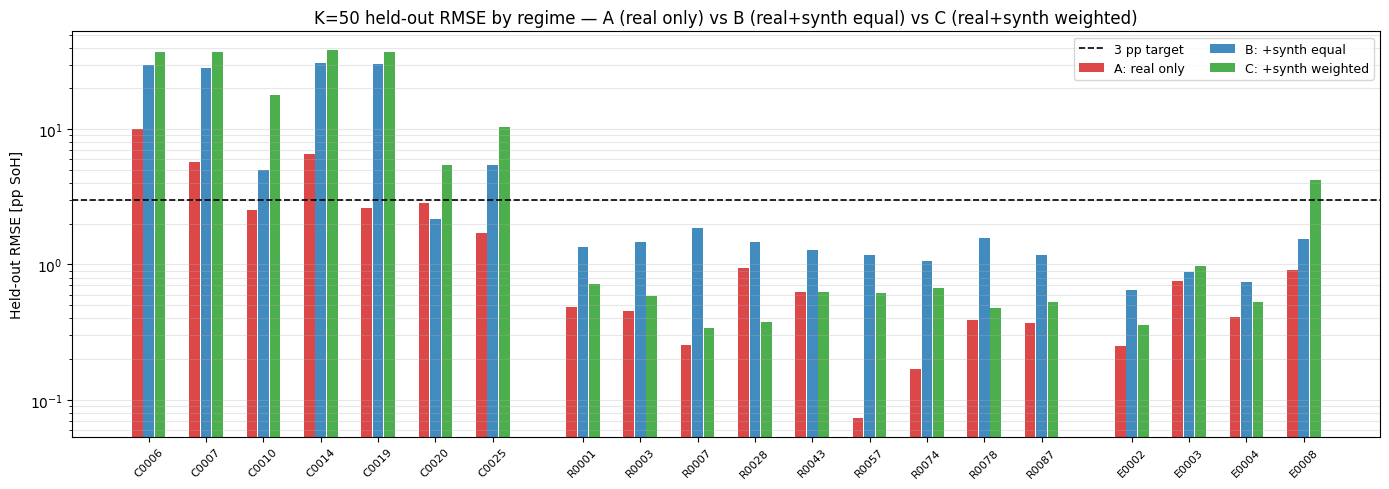

In [5]:
makes = ['CALB', 'REPT', 'EVE']
colors = {'A_real_only': 'tab:red', 'B_equal': 'tab:blue', 'C_weighted': 'tab:green'}
labels = {'A_real_only': 'A: real only', 'B_equal': 'B: +synth equal', 'C_weighted': 'C: +synth weighted'}

fig, ax = plt.subplots(figsize=(14, 5))
xoff = 0
x_positions = []
x_labels = []
for m in makes:
    d = df[df.make == m]
    cell_ids = sorted(d.cell_id.unique())
    for cid in cell_ids:
        for j, regime in enumerate(['A_real_only', 'B_equal', 'C_weighted']):
            r = d[(d.cell_id == cid) & (d.regime == regime)]
            if len(r) == 0: continue
            ax.bar(xoff + j*0.28, r.rmse_pinn_pp.iloc[0], 0.26,
                    color=colors[regime], alpha=0.85,
                    label=labels[regime] if xoff == 0 and j < 3 else '')
        x_positions.append(xoff + 0.28)
        # Short label: manufacturer prefix + last 3 chars of cell id
        cid_short = str(cid).split('_')[-1] if '_' in str(cid) else str(cid)
        x_labels.append(f'{m[:1]}{cid_short}')
        xoff += 1.4
    xoff += 0.8   # gap between makes

ax.axhline(3.0, color='black', ls='--', lw=1.2, label='3 pp target')
ax.set_yscale('log')
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, fontsize=8)
ax.set_ylabel('Held-out RMSE [pp SoH]')
ax.set_title('K=50 held-out RMSE by regime — A (real only) vs B (real+synth equal) vs C (real+synth weighted)')
ax.legend(fontsize=9, loc='upper right', ncol=2)
ax.grid(alpha=0.3, axis='y', which='both')
fig.tight_layout()
plt.show()

## 5. Median comparison — one point per make × regime

/tmp/ipykernel_1724451/2128179917.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = df.groupby(['regime', 'make'])['rmse_pinn_pp'].median().unstack('regime')


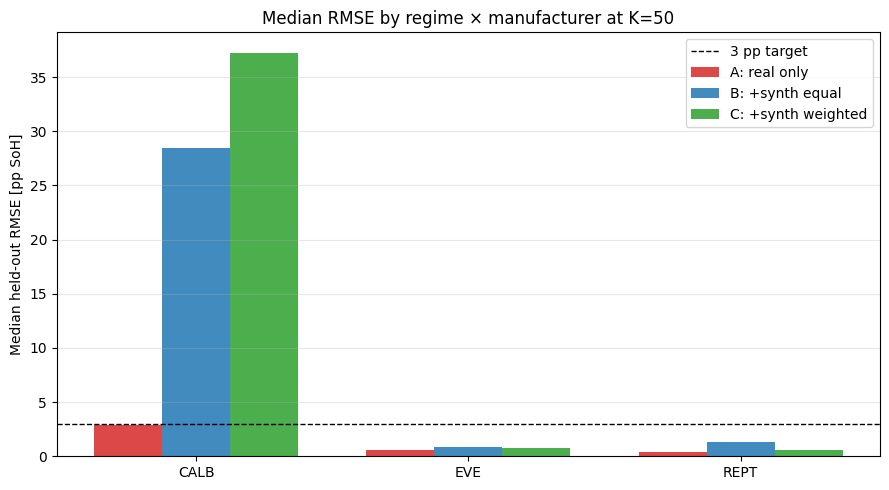


regime  A_real_only  B_equal  C_weighted
make                                    
CALB          2.866   28.498      37.276
EVE           0.585    0.813       0.752
REPT          0.387    1.338       0.584


In [6]:
med = df.groupby(['regime', 'make'])['rmse_pinn_pp'].median().unstack('regime')
med = med[['A_real_only', 'B_equal', 'C_weighted']]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(med.index))
w = 0.25
for i, regime in enumerate(['A_real_only', 'B_equal', 'C_weighted']):
    ax.bar(x + (i-1)*w, med[regime], w, label=labels[regime], color=colors[regime], alpha=0.85)
ax.axhline(3.0, color='black', ls='--', lw=1, label='3 pp target')
ax.set_xticks(x)
ax.set_xticklabels(med.index)
ax.set_ylabel('Median held-out RMSE [pp SoH]')
ax.set_title('Median RMSE by regime × manufacturer at K=50')
ax.legend()
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()
print()
print(med.round(3))

## 6. Decision — does synthetic augmentation warrant abstract update?

Winning criteria for regime C:

- **CALB median improvement ≥ 20% vs A** (CALB in A gives ~2.87 pp; target ≤ 2.30 pp)
- **CALB cells 6, 19 both cross 3 pp target** (both fail in A at ~3.8 pp)
- **REPT/EVE not regressed by more than 0.5 pp median vs A**

The abstract's 8× cycling reduction headline still holds; if C beats A meaningfully, the story becomes: *"PINN augmented with PyBaMM-synthetic trajectories generalises across manufacturers with 8× characterisation reduction — synthetic data teaches the ODE structure without contaminating real-cell fits."*

If C doesn't clearly beat A, ship the v2 (real-only, PyBaMM-informed) abstract and treat synthetic augmentation as follow-up work for the journal paper.

In [7]:
print('=== Decision matrix ===')
dA = df[df.regime == 'A_real_only']
dC = df[df.regime == 'C_weighted']

# CALB improvement
calb_A_med = dA[dA.make == 'CALB'].rmse_pinn_pp.median()
calb_C_med = dC[dC.make == 'CALB'].rmse_pinn_pp.median()
calb_gain_pct = 100 * (calb_A_med - calb_C_med) / calb_A_med if calb_A_med else 0
print(f'CALB median: A={calb_A_med:.2f} pp, C={calb_C_med:.2f} pp   '
      f'(C is {calb_gain_pct:+.1f}% better)   '
      f'{"✓ ≥20% gain" if calb_gain_pct >= 20 else "✗ <20% gain"}')

# Cells 6, 19
for cid_frag in ['CALB_0006', 'CALB_0019']:
    rA = dA[dA.cell_id == cid_frag]
    rC = dC[dC.cell_id == cid_frag]
    if len(rA) and len(rC):
        vA = rA.rmse_pinn_pp.iloc[0]
        vC = rC.rmse_pinn_pp.iloc[0]
        crossed = '✓ crossed 3pp' if vC < 3.0 else '✗ still fails 3pp'
        print(f'{cid_frag}: A={vA:.2f} pp, C={vC:.2f} pp   {crossed}')

# REPT / EVE regression check
for m in ['REPT', 'EVE']:
    a = dA[dA.make == m].rmse_pinn_pp.median()
    c = dC[dC.make == m].rmse_pinn_pp.median()
    delta = c - a
    ok = '✓ no serious regression (<0.5 pp)' if delta < 0.5 else '✗ regressed >0.5 pp'
    print(f'{m} median: A={a:.2f} pp, C={c:.2f} pp   Δ={delta:+.2f}   {ok}')

=== Decision matrix ===
CALB median: A=2.87 pp, C=37.28 pp   (C is -1200.7% better)   ✗ <20% gain
CALB_0006: A=9.97 pp, C=37.42 pp   ✗ still fails 3pp
CALB_0019: A=2.62 pp, C=37.28 pp   ✗ still fails 3pp
REPT median: A=0.39 pp, C=0.58 pp   Δ=+0.20   ✓ no serious regression (<0.5 pp)
EVE median: A=0.58 pp, C=0.75 pp   Δ=+0.17   ✓ no serious regression (<0.5 pp)
